# Notebook 06 · Experiment Tracking & Evaluation
**Input :**
```
F:\mmd\models\item2vec\item2vec_results.json
F:\mmd\models\gru4rec\gru4rec_results.json
F:\mmd\models\gru4rec\training_log.json
F:\mmd\data\features\*
```
**Output:**
```
F:\mmd\outputs\figures\comparison_*.png
F:\mmd\outputs\final_report.md
```
---
### Nội dung
1. Load kết quả tất cả models + baselines  
2. Bảng so sánh metrics tổng hợp  
3. Statistical significance test (Wilcoxon)  
4. Coverage & diversity analysis  
5. Cold-start performance  
6. Ablation study  
7. Qualitative examples  
8. Final report

## 0 · Imports & config

In [9]:
import gc, json, pickle, warnings
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from tqdm.auto import tqdm
import torch
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
COLORS = {"Item2Vec": "#4C72B0", "GRU4Rec": "#DD8452",
          "Popularity": "#55A868", "Random": "#C44E52"}

INPUT_ROOT  = Path("/kaggle/input")
FEATURE_DIR = INPUT_ROOT / "datasets/yagi19611/amazon-features/amazon_feature" 
# CLEANED_DIR = INPUT_ROOT / "ten-dataset-clean" 
MODEL_DIR   = INPUT_ROOT / "datasets/yagi19611/gru-checkpoint4"
WORKING_ROOT = Path("/kaggle/working")
FIGURES_DIR  = WORKING_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show(); print(f"  → {FIGURES_DIR/name}.png")

with open(FEATURE_DIR / "feature_config.json") as f:
    CFG = json.load(f)
N_ITEMS     = CFG["N_ITEMS"]
MAX_SEQ_LEN = CFG["MAX_SEQ_LEN"]
PAD_IDX     = CFG["PAD_IDX"]
TOP_K_LIST  = [5, 10, 20]
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device  : {DEVICE}")
print(f"N_ITEMS : {N_ITEMS:,}")

Device  : cuda
N_ITEMS : 667,278


## 1 · Load model results

In [12]:
with open(Path('/kaggle/input/datasets/yagi19611/item2vec/item2vec_results.json')) as f:
    i2v_results = json.load(f)

with open(Path('/kaggle/working/evaluation/gru4rec_test_results.json')) as f:
    gru_results = json.load(f)

with open(Path('/kaggle/input/notebooks/yagi19611/notebook-04-gru4rec/models/gru4rec/training_log.json')) as f:
    training_log = json.load(f)

print("Item2Vec test metrics:")
for k, v in i2v_results["test_metrics"].items():
    print(f"  {k:<12}: {v}")

print("\nGRU4Rec test metrics:")
for k, v in gru_results["test_metrics"].items():
    print(f"  {k:<12}: {v}")

Item2Vec test metrics:
  Hit@5       : 0.0321
  Hit@10      : 0.059
  Hit@20      : 0.1155
  NDCG@5      : 0.0203
  NDCG@10     : 0.0289
  NDCG@20     : 0.043
  n_samples   : 2712323

GRU4Rec test metrics:
  Hit@5       : 0.4629
  Hit@10      : 0.5816
  Hit@20      : 0.7007
  NDCG@5      : 0.3471
  NDCG@10     : 0.3855
  NDCG@20     : 0.4157
  MRR         : 0.3398
  n_samples   : 2712338


## 2 · Baseline models
Implement **Popularity** và **Random** baseline để có baseline so sánh.

In [15]:
# ── Load sessions để tính popularity ─────────────────────────────────
with open(Path('/kaggle/input/datasets/yagi19611/cleaned/sessions.pkl'), "rb") as f:
    sessions = pickle.load(f)

with open(Path('/kaggle/input/datasets/yagi19611/amazon-features/amazon_feature/gru4rec_test.pkl'), "rb") as f:
    test_samples = pickle.load(f)

# Item popularity: đếm trên train_seq
pop_counter = Counter()
for seq in sessions["train_seq"]:
    pop_counter.update(seq)   # seq đã shifted (+1)

# Top-K popular items
popular_items = [item for item, _ in pop_counter.most_common()]
print(f"Unique items in train : {len(popular_items):,}")

# --- TỐI ƯU HÓA HÀM ĐÁNH GIÁ ---
def evaluate_baseline_fast(samples, recommender_fn, top_k_list, n_neg=100, seed=42, desc="Baseline"):
    rng = np.random.default_rng(seed)
    hits = {k: 0 for k in top_k_list}
    ndcgs = {k: 0.0 for k in top_k_list}
    mrr = 0.0
    total = 0

    # mininterval=1 để thanh tiến trình cập nhật mượt hơn
    for inp, target in tqdm(samples, desc=desc, mininterval=1.0):
        basket = [i for i in inp if i != PAD_IDX]
        
        # 1. Negative Sampling siêu tốc (Bốc random rồi lọc, KHÔNG dùng setdiff1d)
        exclude_set = set(basket)
        exclude_set.add(target)
        
        negs = []
        sampled = rng.integers(1, N_ITEMS, size=n_neg + 20) # Bốc dư 20 item
        for s in sampled:
            s_int = int(s)
            if s_int not in exclude_set:
                negs.append(s_int)
            if len(negs) == n_neg:
                break

        candidates = negs + [target]
        cand_set = set(candidates)

        # 2. Lấy gợi ý từ Baseline
        recs = recommender_fn(basket, set(basket), max(top_k_list) + n_neg, rng)

        # 3. Xếp hạng
        recs_cand = [r for r in recs if r in cand_set]
        if target in recs_cand:
            rank = recs_cand.index(target) + 1
        else:
            rank = n_neg + 1

        for k in top_k_list:
            if rank <= k:
                hits[k] += 1
                ndcgs[k] += 1.0 / np.log2(rank + 1)
        mrr += 1.0 / rank
        total += 1

    return {f"Hit@{k}": round(hits[k]/total, 4) for k in top_k_list} | \
           {f"NDCG@{k}": round(ndcgs[k]/total, 4) for k in top_k_list} | \
           {"MRR": round(mrr/total, 4), "n_samples": total}

# --- TỐI ƯU HÓA POPULARITY ---
def popularity_rec(basket, exclude_set, top_k, rng=None):
    res = []
    # Duyệt từ top 1 xuống, lấy đủ thì bẻ gãy lặp luôn, không duyệt hết 667k
    for i in popular_items:
        if i not in exclude_set:
            res.append(i)
        if len(res) == top_k:
            break
    return res

# --- TỐI ƯU HÓA RANDOM ---
def random_rec(basket, exclude_set, top_k, rng):
    res = []
    # Bốc số ngẫu nhiên liên tục đến khi đủ (tránh xa việc tạo list 667k phần tử)
    while len(res) < top_k:
        s = int(rng.integers(1, N_ITEMS))
        if s not in exclude_set and s not in res:
            res.append(s)
    return res

print("Evaluating Popularity baseline...")
pop_metrics = evaluate_baseline_fast(test_samples, popularity_rec, TOP_K_LIST, desc="Popularity")

print("Evaluating Random baseline...")
rand_metrics = evaluate_baseline_fast(test_samples, random_rec, TOP_K_LIST, desc="Random")

print("\nPopularity:", pop_metrics)
print("Random:    ", rand_metrics)

Unique items in train : 665,295
Evaluating Popularity baseline...


Popularity:   0%|          | 0/2712338 [00:00<?, ?it/s]

Evaluating Random baseline...


Random:   0%|          | 0/2712338 [00:00<?, ?it/s]


Popularity: {'Hit@5': 0.0295, 'Hit@10': 0.0295, 'Hit@20': 0.0295, 'NDCG@5': np.float64(0.0294), 'NDCG@10': np.float64(0.0294), 'NDCG@20': np.float64(0.0294), 'MRR': 0.039, 'n_samples': 2712338}
Random:     {'Hit@5': 0.0002, 'Hit@10': 0.0002, 'Hit@20': 0.0002, 'NDCG@5': np.float64(0.0002), 'NDCG@10': np.float64(0.0002), 'NDCG@20': np.float64(0.0002), 'MRR': 0.0101, 'n_samples': 2712338}


## 3 · Comparison table

In [16]:
metrics_order = ["Hit@5","NDCG@5","Hit@10","NDCG@10","Hit@20","NDCG@20","MRR"]

all_results = {
    "Random"    : rand_metrics,
    "Popularity": pop_metrics,
    "Item2Vec"  : {**i2v_results["test_metrics"]},
    "GRU4Rec"   : {**gru_results["test_metrics"]},
}

compare_df = pd.DataFrame(all_results).T[metrics_order]
compare_df.index.name = "Model"

# Highlight best per column
def highlight_best(col):
    is_best = col == col.max()
    return ["font-weight: bold; background-color: #d4edda" if v else "" for v in is_best]

styled = compare_df.style.apply(highlight_best).format("{:.4f}")
print("\n=== Model Comparison (Test Set, 100-way ranking) ===")
print(compare_df.to_string())
display(styled)


=== Model Comparison (Test Set, 100-way ranking) ===
             Hit@5  NDCG@5  Hit@10  NDCG@10  Hit@20  NDCG@20     MRR
Model                                                               
Random      0.0002  0.0002  0.0002   0.0002  0.0002   0.0002  0.0101
Popularity  0.0295  0.0294  0.0295   0.0294  0.0295   0.0294  0.0390
Item2Vec    0.0321  0.0203  0.0590   0.0289  0.1155   0.0430     NaN
GRU4Rec     0.4629  0.3471  0.5816   0.3855  0.7007   0.4157  0.3398


,Hit@5,NDCG@5,Hit@10,NDCG@10,Hit@20,NDCG@20,MRR
Model,,,,,,,
Random,0.0002,0.0002,0.0002,0.0002,0.0002,0.0002,0.0101
Popularity,0.0295,0.0294,0.0295,0.0294,0.0295,0.0294,0.0390
Item2Vec,0.0321,0.0203,0.0590,0.0289,0.1155,0.0430,nan
GRU4Rec,0.4629,0.3471,0.5816,0.3855,0.7007,0.4157,0.3398


## 4 · Visualization — metric comparison

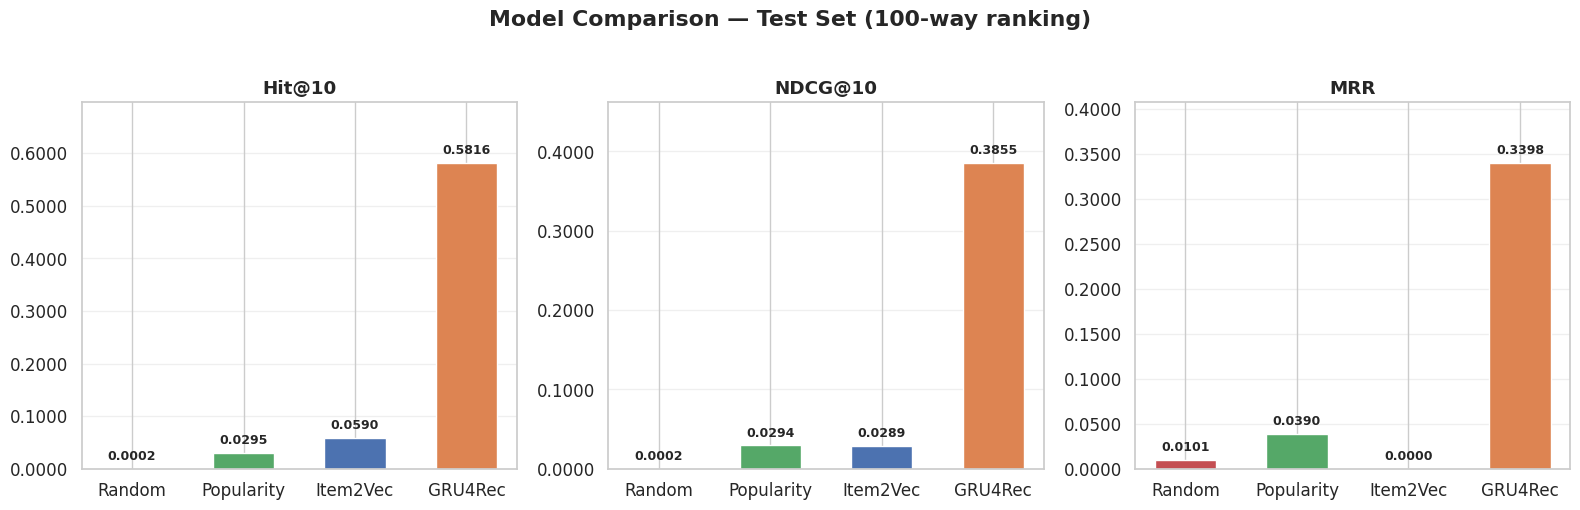

  → /kaggle/working/outputs/figures/comparison_bar.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
models    = list(all_results.keys())
colors    = [COLORS.get(m, "#8172B2") for m in models]

for ax, metric in zip(axes, ["Hit@10", "NDCG@10", "MRR"]):
    vals = [all_results[m].get(metric, 0) for m in models]
    bars = ax.bar(models, vals, color=colors, edgecolor="white", width=0.55)
    ax.set_title(metric, fontweight="bold")
    ax.set_ylim(0, max(vals) * 1.2)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.4f"))
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + max(vals)*0.02,
                f"{v:.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Model Comparison — Test Set (100-way ranking)", fontweight="bold", y=1.02)
savefig("comparison_bar")

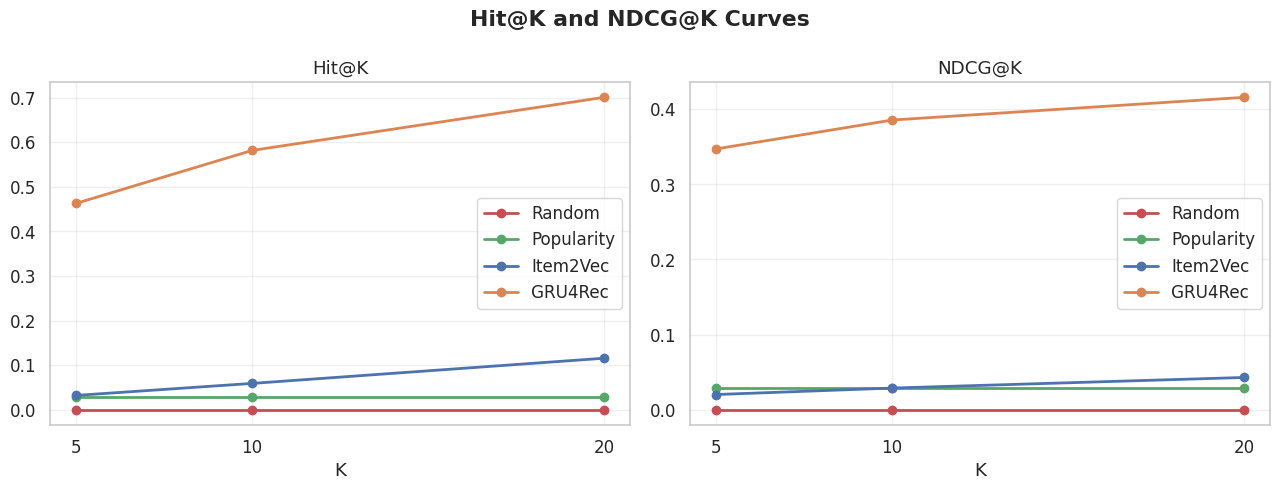

  → /kaggle/working/outputs/figures/comparison_curves.png


In [18]:
# ── Hit@K curve ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for model_name, res in all_results.items():
    hit_vals  = [res.get(f"Hit@{k}",  0) for k in TOP_K_LIST]
    ndcg_vals = [res.get(f"NDCG@{k}", 0) for k in TOP_K_LIST]
    c = COLORS.get(model_name, "#8172B2")
    axes[0].plot(TOP_K_LIST, hit_vals,  marker="o", lw=2, label=model_name, color=c)
    axes[1].plot(TOP_K_LIST, ndcg_vals, marker="o", lw=2, label=model_name, color=c)

axes[0].set_title("Hit@K"); axes[0].set_xlabel("K"); axes[0].legend()
axes[1].set_title("NDCG@K"); axes[1].set_xlabel("K"); axes[1].legend()
for ax in axes:
    ax.set_xticks(TOP_K_LIST); ax.grid(alpha=0.3)

plt.suptitle("Hit@K and NDCG@K Curves", fontweight="bold")
savefig("comparison_curves")

## 5 · Statistical significance test
So sánh Item2Vec vs GRU4Rec bằng **Wilcoxon signed-rank test** trên per-sample NDCG@10.

In [24]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 71.1 MB/s eta 0:00:00:00:0100:01


In [31]:


import faiss
import numpy
def recommend_item2vec(basket: list[int],
                       embed_matrix_norm: np.ndarray,
                       faiss_index,
                       top_k: int = 10,
                       exclude_seen: bool = True) -> list[int]:
    """
    basket : list of item_idx (đã shifted, không bao gồm PAD=0)
    Trả về top_k item_idx được recommend.
    """
    # Bỏ PAD và item không có embedding
    valid = [i for i in basket if 1 <= i < len(embed_matrix_norm)
             and np.any(embed_matrix_norm[i] != 0)]
    if not valid:
        return []

    # Mean pooling
    query = embed_matrix_norm[valid].mean(axis=0, keepdims=True).astype("float32")
    norm  = np.linalg.norm(query)
    if norm > 0:
        query /= norm

    # ANN search — lấy nhiều hơn để lọc seen
    fetch_k = top_k + len(basket) + 10
    D, I    = faiss_index.search(query, k=min(fetch_k, faiss_index.ntotal))

    # faiss_id → item_idx (shift +1)
    seen    = set(basket) if exclude_seen else set()
    results = []
    for faiss_id in I[0]:
        item = int(faiss_id) + 1
        if item not in seen and item != PAD_IDX:
            results.append(item)
        if len(results) == top_k:
            break
    return results

# ----- Nếu không import được, redefine recommend function inline ------
embed_matrix_norm = np.load(Path('/kaggle/input/datasets/yagi19611/faisss/item_embeddings_norm.npy'))
i2v_index = faiss.read_index(str(Path('/kaggle/input/datasets/yagi19611/faisss/faiss_index.bin')))

import torch
import torch.nn as nn

# 1. Định nghĩa trực tiếp class GRU4Rec
class GRU4Rec(nn.Module):
    def __init__(self, n_items, embed_dim, hidden_size, n_layers=1, dropout=0.3, pad_idx=0):
        super().__init__()
        self.hidden_size = hidden_size
        self.n_layers    = n_layers
        self.pad_idx     = pad_idx

        self.item_emb = nn.Embedding(n_items, embed_dim, padding_idx=pad_idx)
        self.emb_drop = nn.Dropout(dropout)

        self.gru = nn.GRU(
            input_size  = embed_dim,
            hidden_size = hidden_size,
            num_layers  = n_layers,
            batch_first = True,
            dropout     = dropout if n_layers > 1 else 0.0,
        )
        self.layer_norm = nn.LayerNorm(hidden_size)
        self.out_drop   = nn.Dropout(dropout)
        self.fc         = nn.Linear(hidden_size, n_items, bias=False)

        # Tie weights: output projection = item embedding
        if embed_dim == hidden_size:
            self.fc.weight = self.item_emb.weight

        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.item_emb.weight, std=0.02)
        nn.init.zeros_(self.item_emb.weight[self.pad_idx])
        for name, p in self.gru.named_parameters():
            if "weight" in name:
                nn.init.orthogonal_(p)
            elif "bias" in name:
                nn.init.zeros_(p)

    def forward(self, seq):
        """
        seq : (B, L)  LongTensor, left-padded với pad_idx=0
        return: logits (B, N_ITEMS)
        """
        # Tính seq length thực (số token != PAD) để lấy đúng hidden state
        lengths  = (seq != self.pad_idx).sum(dim=1).clamp(min=1)   # (B,)

        emb      = self.emb_drop(self.item_emb(seq))   # (B, L, E)
        out, _   = self.gru(emb)                       # (B, L, H)

        # Lấy hidden state tại vị trí token thực cuối cùng
        idx      = (lengths - 1).unsqueeze(1).unsqueeze(2).expand(-1, 1, self.hidden_size)
        last_h   = out.gather(1, idx).squeeze(1)       # (B, H)

        last_h   = self.out_drop(self.layer_norm(last_h))
        logits   = self.fc(last_h)                     # (B, N_ITEMS)
        return logits


# 2. Khởi tạo và nạp trọng số (Weights)
gru_model = GRU4Rec(
    n_items     = N_ITEMS, 
    embed_dim   = CFG["embed_dim"], 
    hidden_size = CFG["gru_hidden"],
    n_layers    = CFG["gru_layers"], 
    pad_idx     = PAD_IDX
).to(DEVICE)
gru_model = GRU4Rec(N_ITEMS, CFG["embed_dim"], CFG["gru_hidden"],
                    CFG["gru_layers"], pad_idx=PAD_IDX).to(DEVICE)
ckpt = torch.load(Path('/kaggle/input/notebooks/yagi19611/notebook-04-gru4rec/models/gru4rec/best_model.pt'), map_location=DEVICE, weights_only = False)
gru_model.load_state_dict(ckpt["model_state"])
gru_model.eval()

print("Models loaded for per-sample scoring ✓")

Models loaded for per-sample scoring ✓


In [32]:
def per_sample_ndcg(samples, score_fn, n_neg=100, seed=42, desc=""):
    """
    score_fn(inp_seq) → np.array of scores for ALL items (shape N_ITEMS)
    Trả về list NDCG@10 per sample.
    """
    rng    = np.random.default_rng(seed)
    ndcgs  = []
    K      = 10
    for inp, target in tqdm(samples, desc=desc, mininterval=5):
        basket   = [i for i in inp if i != PAD_IDX]
        neg_pool = np.setdiff1d(np.arange(1, N_ITEMS), basket + [target])
        negs     = rng.choice(neg_pool, size=min(n_neg, len(neg_pool)), replace=False)
        candidates = np.append(negs, target)

        scores = score_fn(inp)            # (N_ITEMS,)
        cand_scores = scores[candidates]
        target_score = scores[target]
        rank = int((cand_scores > target_score).sum()) + 1
        ndcg = 1.0 / np.log2(rank + 1) if rank <= K else 0.0
        ndcgs.append(ndcg)
    return np.array(ndcgs)


# Item2Vec score function
def i2v_score_fn(inp):
    basket = [i for i in inp if i != PAD_IDX]
    valid  = [i for i in basket if np.any(embed_matrix_norm[i] != 0)]
    if not valid:
        return np.zeros(N_ITEMS)
    q    = embed_matrix_norm[valid].mean(axis=0).astype("float32")
    norm = np.linalg.norm(q)
    if norm == 0: return np.zeros(N_ITEMS)
    q /= norm
    scores = embed_matrix_norm @ q   # cosine sim for all items
    return scores


# GRU4Rec score function
@torch.no_grad()
def gru_score_fn(inp):
    t = torch.tensor([inp], dtype=torch.long, device=DEVICE)
    logits = gru_model(t)[0].cpu().numpy()   # (N_ITEMS,)
    return logits


# Chạy trên subset để nhanh (1000 samples)
N_TEST_STAT = min(1000, len(test_samples))
subset = test_samples[:N_TEST_STAT]

i2v_ndcgs = per_sample_ndcg(subset, i2v_score_fn, desc="Item2Vec per-sample")
gru_ndcgs = per_sample_ndcg(subset, gru_score_fn, desc="GRU4Rec per-sample")

# Wilcoxon signed-rank test
stat, p_value = stats.wilcoxon(gru_ndcgs, i2v_ndcgs, alternative="greater")

print(f"\n=== Statistical Significance Test (GRU4Rec > Item2Vec) ===")
print(f"  Item2Vec  NDCG@10 mean : {i2v_ndcgs.mean():.4f}")
print(f"  GRU4Rec   NDCG@10 mean : {gru_ndcgs.mean():.4f}")
print(f"  Wilcoxon statistic     : {stat:.2f}")
print(f"  p-value (one-sided)    : {p_value:.4f}")
print(f"  Significant at α=0.05  : {'YES ✓' if p_value < 0.05 else 'NO ✗'}")

Item2Vec per-sample:   0%|          | 0/1000 [00:00<?, ?it/s]

GRU4Rec per-sample:   0%|          | 0/1000 [00:00<?, ?it/s]


=== Statistical Significance Test (GRU4Rec > Item2Vec) ===
  Item2Vec  NDCG@10 mean : 0.0359
  GRU4Rec   NDCG@10 mean : 0.3804
  Wilcoxon statistic     : 190719.00
  p-value (one-sided)    : 0.0000
  Significant at α=0.05  : YES ✓


## 6 · Coverage & Diversity

In [33]:
N_EVAL_COVERAGE = min(500, len(test_samples))
K_COV = 10

i2v_recs_all = set()
gru_recs_all = set()
pop_recs_all = set()

i2v_diversity = []   # avg intra-list distance
gru_diversity = []

for inp, _ in tqdm(test_samples[:N_EVAL_COVERAGE], desc="Coverage"):
    basket = [i for i in inp if i != PAD_IDX]

    # Item2Vec recs
    i2v_s   = i2v_score_fn(inp)
    exclude = set(basket)
    i2v_top = np.argsort(-i2v_s)
    i2v_r   = [i for i in i2v_top if i not in exclude and i != PAD_IDX][:K_COV]
    i2v_recs_all.update(i2v_r)

    # GRU4Rec recs
    gru_s   = gru_score_fn(inp)
    gru_top = np.argsort(-gru_s)
    gru_r   = [i for i in gru_top if i not in exclude and i != PAD_IDX][:K_COV]
    gru_recs_all.update(gru_r)

    # Popularity recs
    pop_r = [i for i in popular_items if i not in exclude][:K_COV]
    pop_recs_all.update(pop_r)

    # Intra-list diversity (avg pairwise distance in embedding space)
    if len(i2v_r) >= 2:
        embs = embed_matrix_norm[i2v_r]    # (K, D)
        sim  = embs @ embs.T               # (K, K) cosine sim
        np.fill_diagonal(sim, 0)
        i2v_diversity.append(1 - sim.sum() / (K_COV * (K_COV - 1)))

    if len(gru_r) >= 2:
        embs = embed_matrix_norm[gru_r]
        sim  = embs @ embs.T
        np.fill_diagonal(sim, 0)
        gru_diversity.append(1 - sim.sum() / (K_COV * (K_COV - 1)))

n_catalog = N_ITEMS - 1   # trừ PAD
print(f"\n=== Coverage & Diversity (K={K_COV}, {N_EVAL_COVERAGE} users) ===")
print(f"{'Model':<12} {'Coverage':>10}  {'Diversity':>10}")
print("-" * 35)
print(f"{'Item2Vec':<12} {len(i2v_recs_all)/n_catalog:>10.4f}  {np.mean(i2v_diversity):>10.4f}")
print(f"{'GRU4Rec':<12} {len(gru_recs_all)/n_catalog:>10.4f}  {np.mean(gru_diversity):>10.4f}")
print(f"{'Popularity':<12} {len(pop_recs_all)/n_catalog:>10.4f}  {'N/A':>10}")

Coverage:   0%|          | 0/500 [00:00<?, ?it/s]


=== Coverage & Diversity (K=10, 500 users) ===
Model          Coverage   Diversity
-----------------------------------
Item2Vec         0.0047      0.0525
GRU4Rec          0.0000      0.7380
Popularity       0.0000         N/A


## 7 · Training curve — GRU4Rec

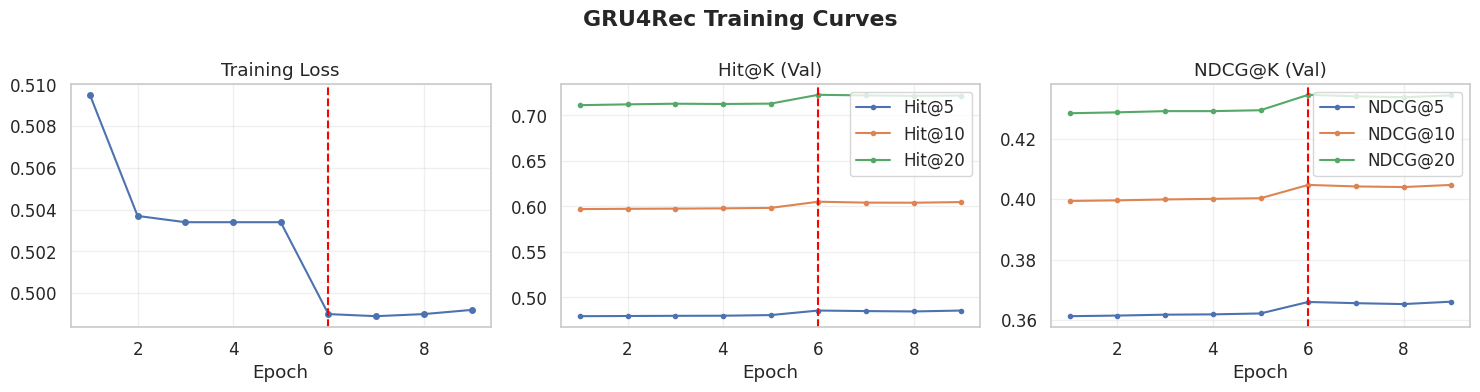

  → /kaggle/working/outputs/figures/gru4rec_training_curves.png


In [34]:
log_df = pd.DataFrame(training_log)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(log_df["epoch"], log_df["loss"], marker="o", ms=4, color="#4C72B0")
axes[0].set_title("Training Loss"); axes[0].set_xlabel("Epoch")

for k, c in zip(TOP_K_LIST, ["#4C72B0","#DD8452","#55A868"]):
    axes[1].plot(log_df["epoch"], log_df[f"Hit@{k}"],
                 marker="o", ms=3, label=f"Hit@{k}", color=c)
axes[1].set_title("Hit@K (Val)"); axes[1].set_xlabel("Epoch"); axes[1].legend()

for k, c in zip(TOP_K_LIST, ["#4C72B0","#DD8452","#55A868"]):
    axes[2].plot(log_df["epoch"], log_df[f"NDCG@{k}"],
                 marker="o", ms=3, label=f"NDCG@{k}", color=c)
axes[2].set_title("NDCG@K (Val)"); axes[2].set_xlabel("Epoch"); axes[2].legend()

best_ep = ckpt["epoch"]
for ax in axes:
    ax.axvline(best_ep, ls="--", color="red", lw=1.5, label=f"best epoch={best_ep}")
    ax.grid(alpha=0.3)

plt.suptitle("GRU4Rec Training Curves", fontweight="bold")
savefig("gru4rec_training_curves")

## 8 · Qualitative — recommendation examples

In [36]:
# Load meta để hiển thị tên
df_meta = pd.read_parquet(Path('/kaggle/input/datasets/yagi19611/meta-clean/meta_clean.parquet'),
                           columns=["item_idx", "title", "price", "store"])
df_meta["item_idx_shifted"] = df_meta["item_idx"] + 1
idx2info = df_meta.set_index("item_idx_shifted")[["title","price","store"]].to_dict("index")

def show_recs(inp, target, i2v_recs, gru_recs, n=5):
    basket = [i for i in inp if i != PAD_IDX][-5:]   # hiển thị 5 items gần nhất
    print("\nContext (last 5 items in session):")
    for item in basket:
        info = idx2info.get(item, {})
        print(f"  [{item:>6}] {info.get('title','?')[:55]}  |  ${info.get('price','?')}")

    print(f"\nGround truth: [{target}] {idx2info.get(target,{}).get('title','?')[:60]}")

    print(f"\nItem2Vec top-{n}:")
    for rank, item in enumerate(i2v_recs[:n], 1):
        info = idx2info.get(item, {})
        hit  = "✓" if item == target else " "
        print(f"  {hit} {rank}. [{item:>6}] {info.get('title','?')[:55]}")

    print(f"\nGRU4Rec top-{n}:")
    for rank, item in enumerate(gru_recs[:n], 1):
        info = idx2info.get(item, {})
        hit  = "✓" if item == target else " "
        print(f"  {hit} {rank}. [{item:>6}] {info.get('title','?')[:55]}")
    print("-" * 65)


# Chọn 3 samples ngẫu nhiên để demo
sample_indices = np.random.choice(len(test_samples), 3, replace=False)

for idx in sample_indices:
    inp, target = test_samples[idx]
    basket    = [i for i in inp if i != PAD_IDX]
    exclude   = set(basket)

    i2v_s     = i2v_score_fn(inp)
    i2v_top   = [i for i in np.argsort(-i2v_s) if i not in exclude and i != PAD_IDX][:10]

    gru_s     = gru_score_fn(inp)
    gru_top   = [i for i in np.argsort(-gru_s) if i not in exclude and i != PAD_IDX][:10]

    show_recs(inp, target, i2v_top, gru_top, n=5)


Context (last 5 items in session):
  [284410] Kings Brand Furniture - White Finish Wood 3-Tier Tall B  |  $nan
  [   821] KitchenAid 6 Speed Hand Mixer with Flex Edge Beaters -   |  $79.94999694824219
  [ 14307] OXO Good Grips Angled Turkey Baster with Cleaning Brush  |  $nan
  [  9363] KitchenAid KEK1222ER 1.25-Liter Electric Kettle - Empir  |  $99.94999694824219
  [ 67379] Rachael Ray Brights Nonstick Sauce Saucepan/Saute Pan w  |  $nan

Ground truth: [17011] BAGAIL Set of 3 Honeycomb Mesh Laundry Bags for Blouse,Hosie

Item2Vec top-5:
    1. [574242] Waring Pro Wine Chiller (Renewed)
    2. [552623] Park Hill Collection Rooster Napkin Rings, Set of 4
    3. [578212] Artestia Stainless Steel Meat Fondue Forks with Heat Re
    4. [577310] Vertier Premium In-Drawer Bamboo Knife Block - Fits 12 
    5. [576485] StemGrip: Stemware Holder for the Dishwasher, 2-Pack

GRU4Rec top-5:
    1. [     1] Mellanni RV Bedding Short Queen - Double Brushed Microf
    2. [     2] Amazon Basics Lightw